# Graph, further cleaning
The graph is collected and stored as:
- json: data/flights_week_graph_with_nut3.json
- 3 csv im data/graph_csv

It is easier to open from json file, operate on domain Graph model and use adapters to convert to other models/formats. For example, you can convert to pandas data frame with GraphPandasAdapter

In [1]:
from graph_creation.adapters.input import GraphJsonLoader
directed_gr = GraphJsonLoader().load("./data/flights_week_graph_with_nut3.json")
directed_gr

Graph(type=DIRECTED, nodes=509, edges=9968, flights=84552, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

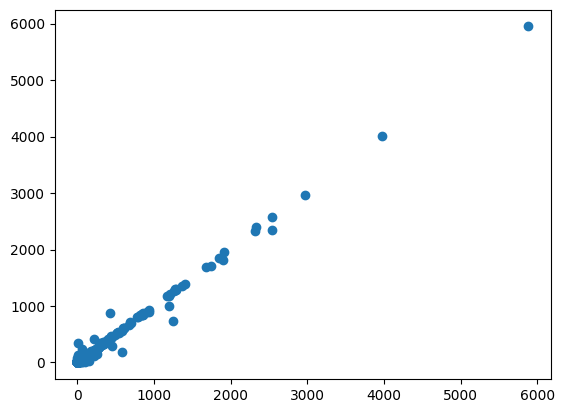

In [8]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
nodes_df = GraphPandasAdapter(directed_gr).nodes_to_df()

import matplotlib.pyplot as plt
plt.scatter(nodes_df['out_flights_number'], nodes_df['in_flights_number'])
plt.show()

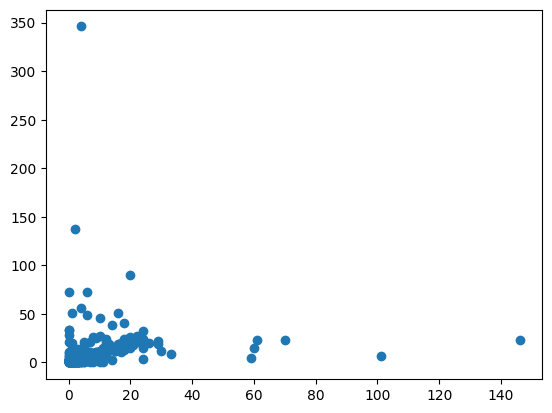

In [9]:
small_nodes_mask = (nodes_df['out_flights_number'] < 25) | (nodes_df['in_flights_number'] < 25)

small_nodes_df = nodes_df[small_nodes_mask]
plt.scatter(small_nodes_df['out_flights_number'], small_nodes_df['in_flights_number'])
plt.show()

In [52]:
# TODO describe why do we use underected graph
und_gr = directed_gr.to_undirected()
und_gr

Graph(type=UNDIRECTED, nodes=509, edges=6174, flights=84552, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [ ]:
# from graph_creation.adapters.output.folium_map import FoliumMapExporter
# FoliumMapExporter().export(und_gr, "final_graph.html")

In [53]:
pa = GraphPandasAdapter(und_gr)

nodes_df = pa.nodes_to_df()
edges_df = pa.edges_to_df()
nodes_df.head()

,id,name,iso_country,iso_region,latitude,longitude,airports,airports_count,out_flights_number,in_flights_number,traffic,nut3_code,node_degree
0,"Alava, ES",Alava,ES,ES-PV,42.882801,-2.724470,LEVT,1,None,None,36,ES11,36
1,"Örebro, SE",Örebro,SE,SE-T,59.223701,15.038000,ESOE,1,None,None,37,SE124,37
2,"Thessaloniki, GR",Thessaloniki,GR,GR-B,40.519280,22.970009,LGTS,1,None,None,640,EL52,640
3,"Kuopio / Siilinjärvi, FI",Kuopio / Siilinjärvi,FI,FI-15,63.007099,27.797800,EFKU,1,None,None,70,FI1DB,70
4,"Kidlington, Oxfordshire, GB","Kidlington, Oxfordshire",GB,GB-ENG,51.836899,-1.320000,EGTK,1,None,None,69,NaN,69


In [54]:
nodes_df.to_csv("./data/graph_csv/undirected_nodes.csv", index=False)
edges_df.to_csv("./data/graph_csv/undirected_edges.csv", index=False)

In [24]:
too_small_nodes_mask = nodes_df['node_degree'] == 1
too_small_nodes_mask.sum()

np.int64(53)

In [28]:
too_small_nodes_df = nodes_df[too_small_nodes_mask]
too_small_nodes_df.head()

,id,name,iso_country,iso_region,latitude,longitude,airports,airports_count,out_flights_number,in_flights_number,traffic,nut3_code,node_degree
50,"Saint-Léger-sur-Roanne, FR",Saint-Léger-sur-Roanne,FR,FR-ARA,46.053818,3.999023,LFLO,1,None,None,1,FRK25,1
52,"Çorlu, TR",Çorlu,TR,TR-59,41.138199,27.919100,LTBU,1,None,None,1,TR211,1
144,"Land's End, Cornwall, GB","Land's End, Cornwall",GB,GB-ENG,50.102798,-5.670560,EGHC,1,None,None,1,NaN,1
171,"Erzurum, TR",Erzurum,TR,TR-25,39.956501,41.170200,LTCE,1,None,None,1,TRA11,1
188,"Kithira Island, GR",Kithira Island,GR,GR-I,36.273978,23.016719,LGKC,1,None,None,1,EL30,1


In [33]:
nodes_ids = list(too_small_nodes_df.id)
und_gr_without_small_nodes = und_gr.copy()
und_gr_without_small_nodes.drop_nodes(nodes_ids)

Graph(type=UNDIRECTED, nodes=456, edges=6121, flights=84499, countries=31, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [39]:
# TODO the problem of Oxfordshire - cypris not Akrotiri, CY
id = "Carterton, Oxfordshire, GB"
mask = (edges_df['from_id'] == id) | (edges_df['to_id'] == id)
edges_df[mask]

,from_id,to_id,weight,distance,Lufthansa Group (passenger),Air France–KLM Group,IAG (Iberia/Vueling/Aer Lingus),Turkish Airlines (hub carrier),Nordics / North Atlantic flag carriers,Southern Europe flag carriers,...,Airbus A330 family (incl. freighter/P2F strings),Airbus A350 family,Other Airbus widebodies (A300/A310/A340/A380),Boeing 777 family (incl. freighter),Boeing 787 family (Dreamliner),Boeing 767 family (incl. cargo conversions),Boeing 757 family (incl. SF/PCF),Boeing 747 family (incl. 747-8F),Eastern heavy cargo (An-124 etc.),Unknown / missing / not matched
869,"Akrotiri, CY","Carterton, Oxfordshire, GB",29,3342.66,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
870,"Carterton, Oxfordshire, GB","North Connel, GB",1,579.95,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
871,"Carterton, Oxfordshire, GB","Land's End, Cornwall, GB",1,339.92,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3250,"Carterton, Oxfordshire, GB","Hannover, DE",2,772.87,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3251,"Carterton, Oxfordshire, GB","Porto, PT",1,1286.48,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3252,"Carterton, Oxfordshire, GB","Lincoln, Lincolnshire, GB",1,180.91,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3253,"Carterton, Oxfordshire, GB","Lossiemouth, Moray, GB",1,671.65,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3604,"Carterton, Oxfordshire, GB","Jasionka, PL",1,1657.16,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4483,"Carterton, Oxfordshire, GB","Warton, GB",1,238.45,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4699,"Carterton, Oxfordshire, GB","Glasgow, GB",1,494.94,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Embedings

In [34]:
import json 
with open("./data/embedings_from_callsign.json") as f:
    callsign_dct = json.load(f)

with open("./data/embedings_from_icao.json") as f:
    icao_dct = json.load(f)

with open("./data/icao_to_model.json") as f:
    icao_to_model = json.load(f)

from graph_creation.domain.graph import Embedding
callsign_embedings_lst: list[Embedding] = []
icao_embedings_lst: list[Embedding] = []

for group in callsign_dct['groups']:
    callsign_embedings_lst.append(Embedding(
        name=group['label'],
        matching_columns=group['codes']
    ))
for group in icao_dct['groups']:
    icao_embedings_lst.append(Embedding(
        name=group['label'],
        matching_columns=group['model_contains']
    ))

In [ ]:
und_gr.create_edge_embeddings(callsign_embedings_lst, icao_embedings_lst, icao_to_model, assign_to_edges=True)

(6174, 51)

In [40]:
edges_df = pa.edges_to_df(with_embedings=True)
edges_df.head()

,from_id,to_id,weight,distance,Lufthansa Group (passenger),Air France–KLM Group,IAG (Iberia/Vueling/Aer Lingus),Turkish Airlines (hub carrier),Nordics / North Atlantic flag carriers,Southern Europe flag carriers,...,Airbus A330 family (incl. freighter/P2F strings),Airbus A350 family,Other Airbus widebodies (A300/A310/A340/A380),Boeing 777 family (incl. freighter),Boeing 787 family (Dreamliner),Boeing 767 family (incl. cargo conversions),Boeing 757 family (incl. SF/PCF),Boeing 747 family (incl. 747-8F),Eastern heavy cargo (An-124 etc.),Unknown / missing / not matched
0,"Aalborg, DK","Billund, DK",3,156.52,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,"Aalborg, DK","Oslo (Gardermoen), NO",11,352.11,0,0,0,0,8,0,...,0,0,0,0,0,0,0,0,0,0
2,"Aalborg, DK","Copenhagen, DK",167,238.40,0,0,0,0,83,0,...,0,0,0,0,0,0,0,0,0,0
3,"Aalborg, DK","Amsterdam, NL",57,624.13,0,56,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,"Aalborg, DK","Málaga, ES",6,2507.05,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
d = edges_df[edges_df['to_id'] == 'Carterton, Oxfordshire, GB']
for c in d.columns:
    print(c, d[c].iloc[0])

from_id Akrotiri, CY
to_id Carterton, Oxfordshire, GB
weight 29
distance 3342.66
Lufthansa Group (passenger) 0
Air France–KLM Group 0
IAG (Iberia/Vueling/Aer Lingus) 0
Turkish Airlines (hub carrier) 0
Nordics / North Atlantic flag carriers 0
Southern Europe flag carriers 0
Swiss regionals / leisure (non-Lufthansa-group) 0
Central/Eastern Europe & Benelux flag carriers 0
Ryanair Group 0
easyJet (all AOCs) 0
Wizz Air 0
Other major EU LCC / leisure-LCC 0
EU leisure / charter airlines 0
DHL Aviation 0
European cargo network carriers 0
Global cargo / integrators 0
Middle East global hubs 0
Other intercontinental majors 0
Business aviation / fractional 0
Special mission / air ambulance / misc ops 29
Other / long tail operators 0
Military / state / special mission 27
Helicopters / rotorcraft 0
Business jets — Gulfstream family 0
Business jets — Bombardier Challenger / Global 0
Business jets — Dassault Falcon family 0
Business jets — Cessna Citation family 8
Business jets — Embraer executive (

In [50]:
edges_df['Special mission / air ambulance / misc ops'].sum()

np.int64(134)